<a href="https://colab.research.google.com/github/AlejoCNYT/Curso_CENDES/blob/main/notebook_ml_uci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson #2

# Machine Learning: Árbol de Decisión y Bosques Aleatorios
## Dataset: Adult Income (Census Income) — UCI ML Repository

---

## Tabla de Contenidos

1. [Instalación y Configuración](#1-instalacion)
2. [Carga y Exploración de Datos](#2-exploracion)
3. [Preparación de Datos](#3-preparacion)
4. [Modelos Base (sin tuning)](#4-modelos-base)
5. [Búsqueda de Hiperparámetros — Árbol de Decisión](#5-tuning-arbol)
6. [Búsqueda de Hiperparámetros — Bosques Aleatorios](#6-tuning-bosque)
7. [Evaluación Final y Comparación de Modelos](#7-evaluacion)
8. [Interpretabilidad](#8-interpretabilidad)
9. [Conclusiones](#9-conclusiones)

---

**Objetivo:** Predecir si el ingreso anual de una persona supera los $50,000 USD usando características del censo de EE.UU.  
**Tarea:** Clasificación binaria (`<=50K` vs `>50K`)  
**Algoritmos:** DecisionTreeClassifier, RandomForestClassifier (scikit-learn)

---
## 1. Instalación y Configuración <a id='1-instalacion'></a>

Instalamos las librerías necesarias y configuramos el entorno de trabajo con semillas fijas para reproducibilidad.

In [29]:
# Instalar dependencias (necesario en Google Colab)
!pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn imbalanced-learn --quiet

In [30]:
# ─── Librerías estándar ───────────────────────────────────────────────────────
import warnings
import time
import os

warnings.filterwarnings('ignore')

# ─── Manipulación de datos ────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Dataset UCI ─────────────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

# ─── Preprocesamiento ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ─── Modelos ─────────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# ─── Métricas ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

# ─── Distribuciones para búsqueda aleatoria ──────────────────────────────────
from scipy.stats import randint

# ─── Persistencia de modelos ─────────────────────────────────────────────────
import joblib

# ─── Semilla global ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ─── Estilo de gráficos ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print(' Entorno configurado correctamente.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
import sklearn; print(f'   Sklearn: {sklearn.__version__}')

 Entorno configurado correctamente.
   NumPy  : 2.0.2
   Pandas : 2.2.2
   Sklearn: 1.6.1


---
## 2. Carga y Exploración de Datos <a id='2-exploracion'></a>

Descargamos el dataset **Adult Income** directamente desde el UCI ML Repository. Contiene datos del censo de EE.UU. de 1994 con **48,842 registros** y **14 atributos**. La variable objetivo es el nivel de ingresos (≤50K o >50K).

In [31]:
# Descargar dataset desde UCI ML Repository
print('Descargando dataset Adult Income (id=2)...')
adult = fetch_ucirepo(id=2)

# Separar características y variable objetivo
X_raw = adult.data.features.copy()
y_raw = adult.data.targets.copy()

# Construir DataFrame completo para exploración
df = pd.concat([X_raw, y_raw], axis=1)

print(f'   Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Variable objetivo: "{y_raw.columns[0]}"')
print(f'   Clases únicas    : {y_raw.iloc[:, 0].unique().tolist()}')

Descargando dataset Adult Income (id=2)...
   Dataset cargado: 48,842 filas × 15 columnas
   Variable objetivo: "income"
   Clases únicas    : ['<=50K', '>50K', '<=50K.', '>50K.']


In [32]:
# Primeras filas del dataset
print('── Primeras 5 filas ──')
df.head()

── Primeras 5 filas ──


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [33]:
# Información general del DataFrame
print('── Información del dataset ──')
df.info()

── Información del dataset ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [34]:
# Estadísticas descriptivas (variables numéricas)
print('── Estadísticas descriptivas ──')
df.describe().round(2)

── Estadísticas descriptivas ──


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


In [35]:
# Análisis de valores nulos
print('── Valores nulos por columna ──')
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]

if resumen_nulos.empty:
    print('   No hay valores nulos explícitos (NaN).')
else:
    print(resumen_nulos)

# Verificar valores '?' que suelen representar missing en este dataset
print('\n── Registros con "?" por columna ──')
interrogantes = (df == '?').sum()
interrogantes = interrogantes[interrogantes > 0]
if interrogantes.empty:
    print('   Ninguno.')
else:
    for col, count in interrogantes.items():
        print(f'   {col}: {count} ({count/len(df)*100:.2f}%)')

── Valores nulos por columna ──
                Nulos  Porcentaje (%)
workclass         963            1.97
occupation        966            1.98
native-country    274            0.56

── Registros con "?" por columna ──
   workclass: 1836 (3.76%)
   occupation: 1843 (3.77%)
   native-country: 583 (1.19%)


In [36]:
# Análisis de duplicados
duplicados = df.duplicated().sum()
print(f'── Registros duplicados: {duplicados} ({duplicados/len(df)*100:.2f}%)')

── Registros duplicados: 29 (0.06%)


In [37]:
# Distribución de la variable objetivo
target_col = y_raw.columns[0]
vc = df[target_col].value_counts()
vc_pct = df[target_col].value_counts(normalize=True).mul(100).round(2)

print('── Distribución de la variable objetivo ──')
dist_df = pd.DataFrame({'Conteo': vc, 'Porcentaje (%)': vc_pct})
print(dist_df)

── Distribución de la variable objetivo ──
        Conteo  Porcentaje (%)
income                        
<=50K    24720           50.61
<=50K.   12435           25.46
>50K      7841           16.05
>50K.     3846            7.87


### 2.1 Visualizaciones Exploratorias

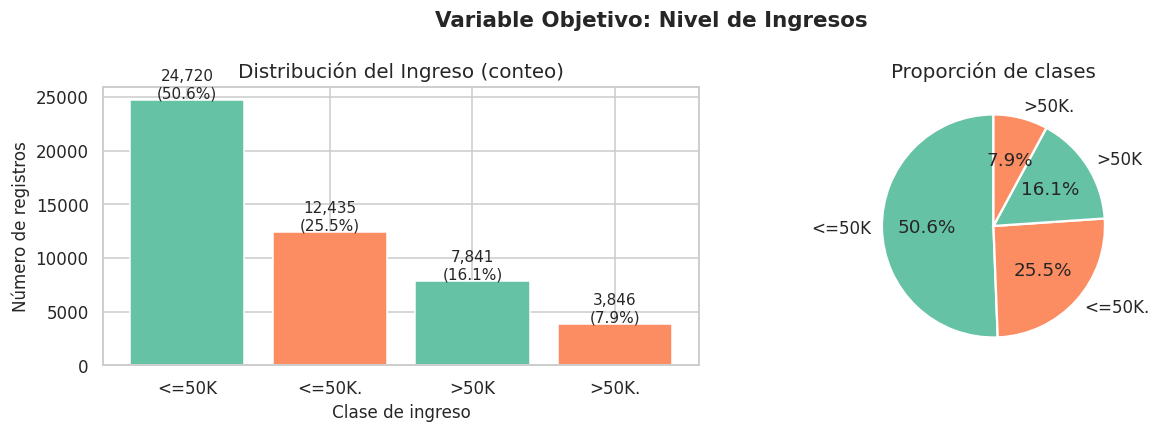

💡 Observación: Existe un desbalance de clases (~75% vs ~25%). Esto afecta la selección de métricas.


In [38]:
# ── Visualización 1: Distribución de la variable objetivo ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = sns.color_palette('Set2', 2)

# Barplot
axes[0].bar(vc.index, vc.values, color=colors)
for i, (idx, val) in enumerate(vc.items()):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Distribución del Ingreso (conteo)')
axes[0].set_ylabel('Número de registros')
axes[0].set_xlabel('Clase de ingreso')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción de clases')

plt.suptitle('Variable Objetivo: Nivel de Ingresos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Observación: Existe un desbalance de clases (~75% vs ~25%). Esto afecta la selección de métricas.')

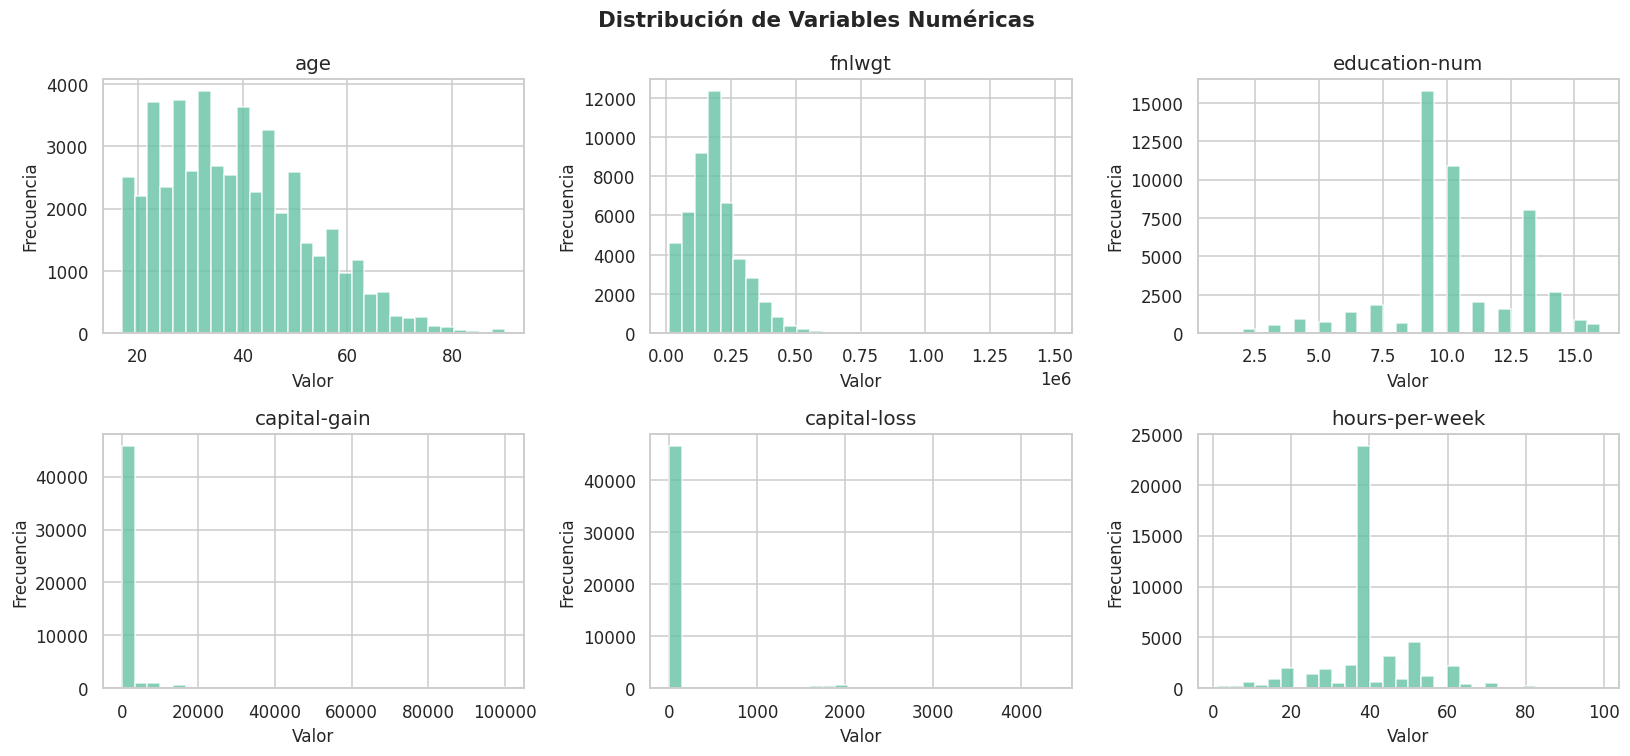

In [39]:
# ── Visualización 2: Distribución de variables numéricas ─────────────────────
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

n_cols_plot = 3
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, n_rows_plot * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=colors[0], edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

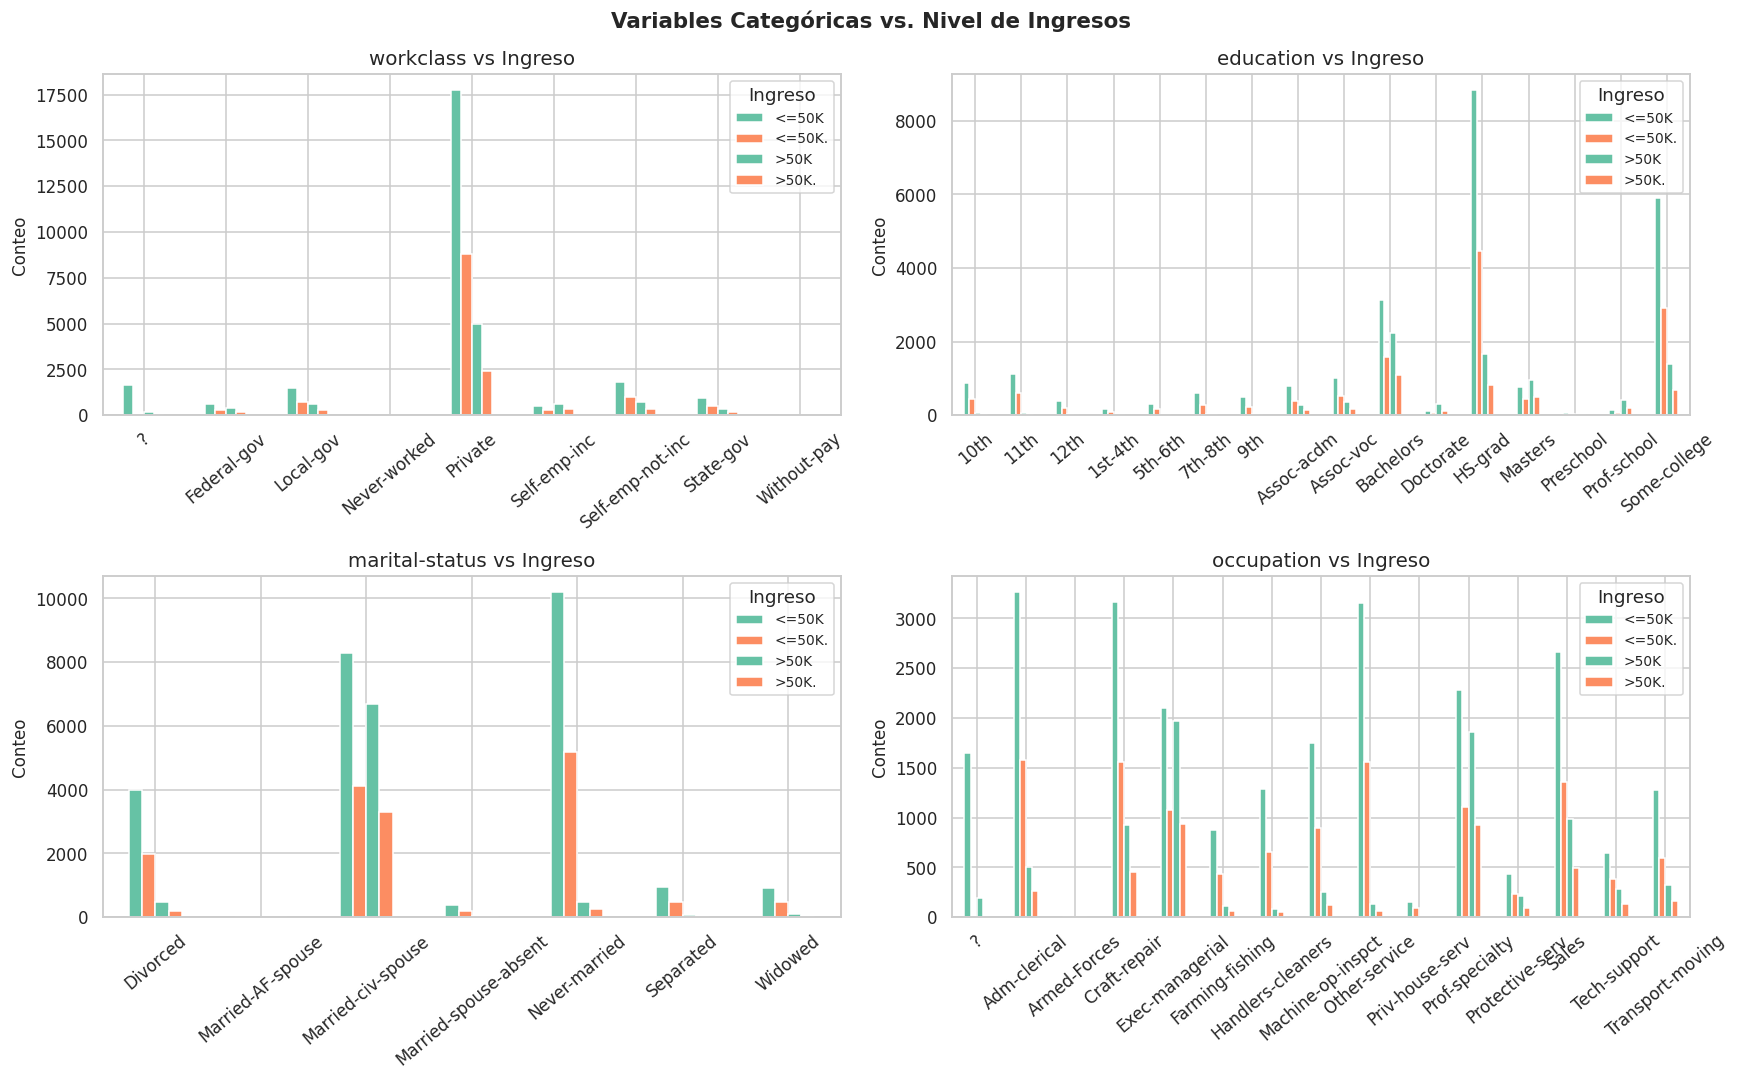

In [40]:
# ── Visualización 3: Variables categóricas vs. ingreso ───────────────────────
cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
# Seleccionamos las 4 más relevantes para no saturar el gráfico
cat_plot = ['workclass', 'education', 'marital-status', 'occupation'] if all(
    c in cat_cols for c in ['workclass', 'education', 'marital-status', 'occupation']
) else cat_cols[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot):
    temp = df.groupby([col, target_col]).size().unstack(fill_value=0)
    temp.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white')
    axes[i].set_title(f'{col} vs Ingreso')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Conteo')
    axes[i].tick_params(axis='x', rotation=40)
    axes[i].legend(title='Ingreso', fontsize=9)

plt.suptitle('Variables Categóricas vs. Nivel de Ingresos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

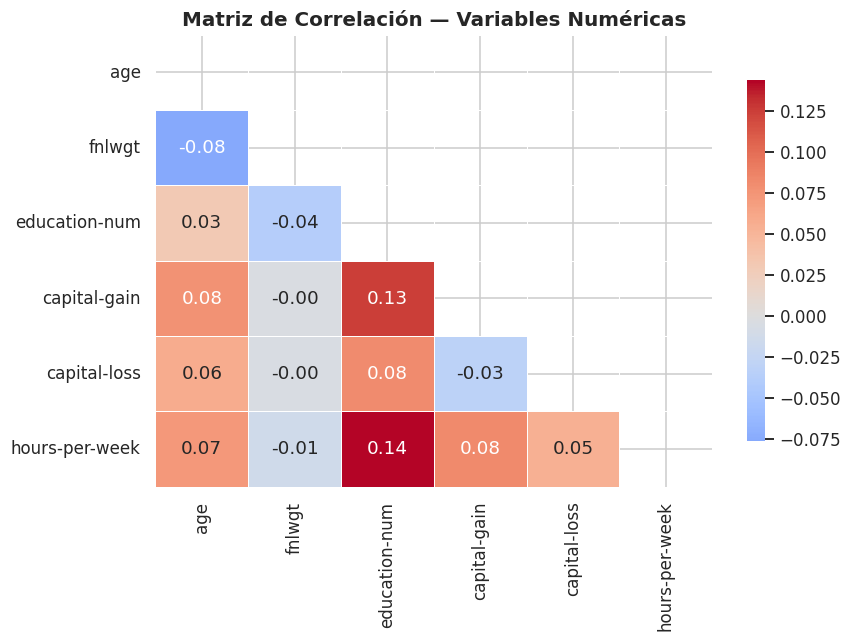

Observación: Las correlaciones entre variables numéricas son en general bajas.


In [41]:
# ── Visualización 4: Matriz de correlación (variables numéricas) ──────────────
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observación: Las correlaciones entre variables numéricas son en general bajas.')

---
## 3. Preparación de Datos <a id='3-preparacion'></a>

Realizamos la preparación en este orden:
1. **Limpieza**: duplicados, valores `?` → NaN, imputación
2. **Encoding**: LabelEncoder para `y`, OneHotEncoder para features categóricas
3. **Escalado**: StandardScaler para features numéricas
4. **División**: 80% train / 20% test estratificado

Todo el preprocesamiento se encapsula en un `ColumnTransformer` dentro de un `Pipeline` de scikit-learn.

In [42]:
# ── 3a. Limpieza ──────────────────────────────────────────────────────────────
df_clean = df.copy()

# Reemplazar '?' por NaN
df_clean.replace('?', np.nan, inplace=True)
print(f'Registros iniciales : {len(df_clean):,}')

# Eliminar duplicados
n_antes = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Duplicados eliminados: {n_antes - len(df_clean)}')
print(f'Registros finales   : {len(df_clean):,}')

# Reconstruir X e y desde el DataFrame limpio
target_col = y_raw.columns[0]
feature_cols = [c for c in df_clean.columns if c != target_col]
X = df_clean[feature_cols].copy()
y_str = df_clean[target_col].copy()

# Identificar columnas numéricas y categóricas
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'\nFeatures numéricas  ({len(num_features)}): {num_features}')
print(f'Features categóricas({len(cat_features)}): {cat_features}')

Registros iniciales : 48,842
Duplicados eliminados: 29
Registros finales   : 48,813

Features numéricas  (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Features categóricas(8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [43]:
# ── 3b. Encoding de la variable objetivo ─────────────────────────────────────
le = LabelEncoder()

# Limpiar espacios y caracteres extraños en y
y_str_clean = y_str.str.strip().str.replace('.', '', regex=False)
y = le.fit_transform(y_str_clean)

print('── Codificación de la variable objetivo ──')
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f'   "{cls}" → {enc}')
print(f'\nDistribución: {np.bincount(y)} (clase 0 / clase 1)')

── Codificación de la variable objetivo ──
   "<=50K" → 0
   ">50K" → 1

Distribución: [37128 11685] (clase 0 / clase 1)


In [44]:
# ── 3d. División train/test (antes de construir Pipeline, para no contaminar) ─
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('── Forma de los conjuntos ──')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')
print(f'   y_train : {y_train.shape}  | distribución: {np.bincount(y_train)}')
print(f'   y_test  : {y_test.shape}   | distribución: {np.bincount(y_test)}')

── Forma de los conjuntos ──
   X_train : (39050, 14)
   X_test  : (9763, 14)
   y_train : (39050,)  | distribución: [29702  9348]
   y_test  : (9763,)   | distribución: [7426 2337]


In [45]:
# ── 3b-c. ColumnTransformer: imputación + escalado/encoding ──────────────────

# Pipeline para variables numéricas: imputar con mediana → escalar
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Pipeline para variables categóricas: imputar con moda → one-hot encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer combinado
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features),
])

print(' Preprocesador construido.')
print(f'   - Numéricas  ({len(num_features)}): imputar mediana + StandardScaler')
print(f'   - Categóricas({len(cat_features)}): imputar moda + OneHotEncoder')

 Preprocesador construido.
   - Numéricas  (6): imputar mediana + StandardScaler
   - Categóricas(8): imputar moda + OneHotEncoder


---
## 4. Modelos Base (sin tuning) <a id='4-modelos-base'></a>

Entrenamos ambos modelos con parámetros por defecto para establecer un **baseline** de rendimiento. Cada modelo se encapsula en un `Pipeline` con el preprocesador definido anteriormente.

In [46]:
# ── Función auxiliar para evaluar modelos ────────────────────────────────────
def evaluar_modelo(modelo, X_tr, X_te, y_tr, y_te, nombre='Modelo'):
    """Entrena, predice y muestra métricas + matriz de confusión."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    print(f'\n{'─'*55}')
    print(f'  {nombre}')
    print(f'{'─'*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    # Matriz de confusión
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'Matriz de Confusión — {nombre}')
    ax.set_ylabel('Valor Real')
    ax.set_xlabel('Valor Predicho')
    plt.tight_layout()
    plt.show()

    return {'nombre': nombre, 'modelo': modelo,
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc,
            'y_pred': y_pred, 'y_prob': y_prob}

print(' Función evaluar_modelo definida.')

 Función evaluar_modelo definida.



───────────────────────────────────────────────────────
  Árbol de Decisión — Base
───────────────────────────────────────────────────────
  Accuracy  : 0.8203
  Precision : 0.6226
  Recall    : 0.6333
  F1-Score  : 0.6279
  ROC-AUC   : 0.7562

              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      7426
        >50K       0.62      0.63      0.63      2337

    accuracy                           0.82      9763
   macro avg       0.75      0.76      0.75      9763
weighted avg       0.82      0.82      0.82      9763



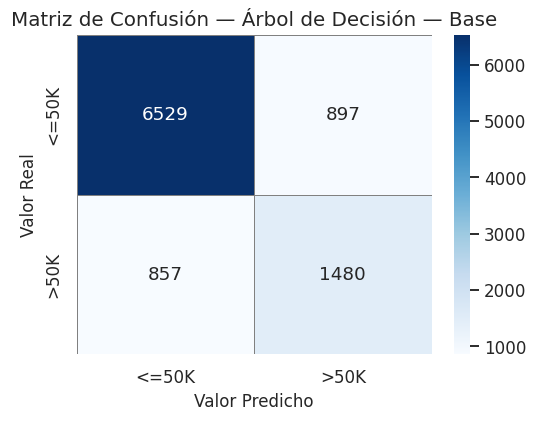

In [47]:
# ── 4.1 Árbol de Decisión base ───────────────────────────────────────────────
pipe_dt_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

res_dt_base = evaluar_modelo(
    pipe_dt_base, X_train, X_test, y_train, y_test,
    nombre='Árbol de Decisión — Base'
)


───────────────────────────────────────────────────────
  Random Forest — Base
───────────────────────────────────────────────────────
  Accuracy  : 0.8549
  Precision : 0.7326
  Recall    : 0.6200
  F1-Score  : 0.6716
  ROC-AUC   : 0.9046

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7426
        >50K       0.73      0.62      0.67      2337

    accuracy                           0.85      9763
   macro avg       0.81      0.77      0.79      9763
weighted avg       0.85      0.85      0.85      9763



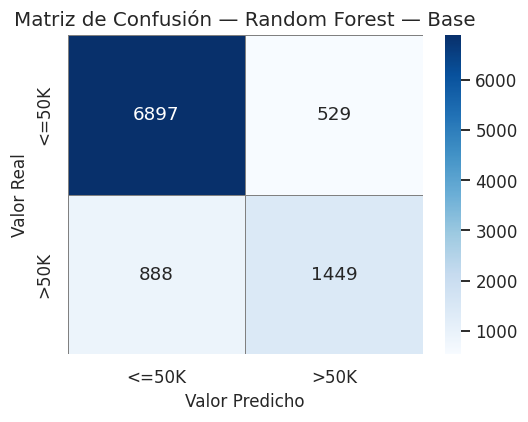

In [48]:
# ── 4.2 Random Forest base ───────────────────────────────────────────────────
pipe_rf_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

res_rf_base = evaluar_modelo(
    pipe_rf_base, X_train, X_test, y_train, y_test,
    nombre='Random Forest — Base'
)

---
## 5. Búsqueda de Hiperparámetros — Árbol de Decisión <a id='5-tuning-arbol'></a>

Usamos dos estrategias de búsqueda:
- **GridSearchCV**: búsqueda exhaustiva en una grilla fija de parámetros
- **RandomizedSearchCV**: muestreo aleatorio del espacio de parámetros (más eficiente con espacios grandes)

Ambas usan validación cruzada con 5 folds y F1-weighted como métrica de optimización.

### 5a. GridSearchCV — Árbol de Decisión

In [49]:
# Parámetros del Grid (notar el prefijo 'model__' por el Pipeline)
param_grid_dt = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy'],
}

pipe_dt_gs = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

grid_dt = GridSearchCV(
    pipe_dt_gs, param_grid_dt,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)

print(' Ejecutando GridSearchCV para Árbol de Decisión...')
t0 = time.time()
grid_dt.fit(X_train, y_train)
tiempo_grid_dt = time.time() - t0

print(f' Completado en {tiempo_grid_dt:.1f} s')
print(f'   Mejor CV F1-weighted: {grid_dt.best_score_:.4f}')
print(f'   Mejores parámetros  : {grid_dt.best_params_}')

 Ejecutando GridSearchCV para Árbol de Decisión...
 Completado en 241.1 s
   Mejor CV F1-weighted: 0.8506
   Mejores parámetros  : {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}



───────────────────────────────────────────────────────
  Árbol de Decisión — GridSearch
───────────────────────────────────────────────────────
  Accuracy  : 0.8667
  Precision : 0.7891
  Recall    : 0.6050
  F1-Score  : 0.6849
  ROC-AUC   : 0.9084

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      7426
        >50K       0.79      0.61      0.68      2337

    accuracy                           0.87      9763
   macro avg       0.84      0.78      0.80      9763
weighted avg       0.86      0.87      0.86      9763



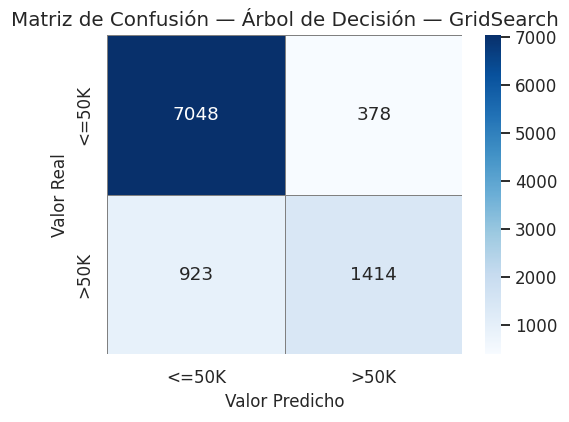

In [50]:
# Evaluar el mejor modelo de GridSearch en test
res_dt_gs = evaluar_modelo(
    grid_dt.best_estimator_, X_train, X_test, y_train, y_test,
    nombre='Árbol de Decisión — GridSearch'
)

### 5b. RandomizedSearchCV — Árbol de Decisión

In [51]:
param_dist_dt = {
    'model__max_depth': randint(1, 20),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
    'model__criterion': ['gini', 'entropy'],
}

pipe_dt_rs = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

rand_dt = RandomizedSearchCV(
    pipe_dt_rs, param_dist_dt,
    n_iter=50, cv=5, scoring='f1_weighted',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)

print(' Ejecutando RandomizedSearchCV para Árbol de Decisión...')
t0 = time.time()
rand_dt.fit(X_train, y_train)
tiempo_rand_dt = time.time() - t0

print(f' Completado en {tiempo_rand_dt:.1f} s')
print(f'   Mejor CV F1-weighted: {rand_dt.best_score_:.4f}')
print(f'   Mejores parámetros  : {rand_dt.best_params_}')

 Ejecutando RandomizedSearchCV para Árbol de Decisión...
 Completado en 127.0 s
   Mejor CV F1-weighted: 0.8503
   Mejores parámetros  : {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__min_samples_split': 13}



───────────────────────────────────────────────────────
  Árbol de Decisión — RandomizedSearch
───────────────────────────────────────────────────────
  Accuracy  : 0.8666
  Precision : 0.7889
  Recall    : 0.6046
  F1-Score  : 0.6846
  ROC-AUC   : 0.9081

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      7426
        >50K       0.79      0.60      0.68      2337

    accuracy                           0.87      9763
   macro avg       0.84      0.78      0.80      9763
weighted avg       0.86      0.87      0.86      9763



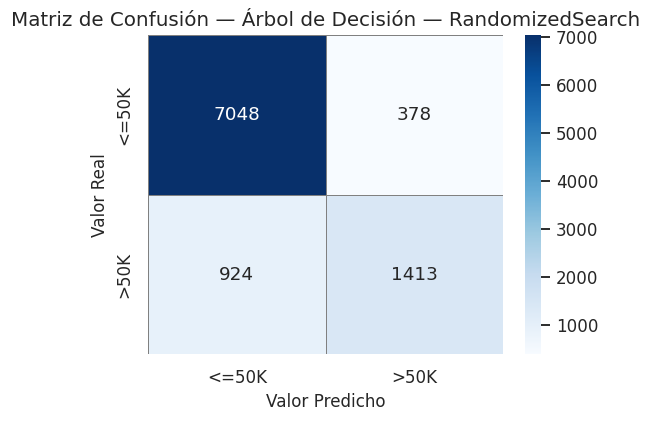

In [52]:
# Evaluar el mejor modelo de RandomizedSearch en test
res_dt_rs = evaluar_modelo(
    rand_dt.best_estimator_, X_train, X_test, y_train, y_test,
    nombre='Árbol de Decisión — RandomizedSearch'
)

### 5c. Comparación GridSearch vs RandomizedSearch — Árbol de Decisión

In [53]:
comp_dt = pd.DataFrame([
    {
        'Método': 'GridSearchCV',
        'Mejor CV F1 (weighted)': f'{grid_dt.best_score_:.4f}',
        'F1 en Test': f'{res_dt_gs["f1"]:.4f}',
        'ROC-AUC Test': f'{res_dt_gs["roc_auc"]:.4f}',
        'Tiempo (s)': f'{tiempo_grid_dt:.1f}',
        'Combinaciones evaluadas': 5*3*3*2,
    },
    {
        'Método': 'RandomizedSearchCV',
        'Mejor CV F1 (weighted)': f'{rand_dt.best_score_:.4f}',
        'F1 en Test': f'{res_dt_rs["f1"]:.4f}',
        'ROC-AUC Test': f'{res_dt_rs["roc_auc"]:.4f}',
        'Tiempo (s)': f'{tiempo_rand_dt:.1f}',
        'Combinaciones evaluadas': 50,
    },
])

print('── Comparación de métodos de búsqueda — Árbol de Decisión ──')
comp_dt.set_index('Método')

── Comparación de métodos de búsqueda — Árbol de Decisión ──


,Mejor CV F1 (weighted),F1 en Test,ROC-AUC Test,Tiempo (s),Combinaciones evaluadas
Método,,,,,
GridSearchCV,0.8506,0.6849,0.9084,241.1,90
RandomizedSearchCV,0.8503,0.6846,0.9081,127.0,50


---
## 6. Búsqueda de Hiperparámetros — Bosques Aleatorios <a id='6-tuning-bosque'></a>

Aplicamos la misma metodología al Random Forest. Este modelo tiene más hiperparámetros y es más costoso computacionalmente, por lo que RandomizedSearchCV ofrece una ventaja mayor aquí.

### 6a. GridSearchCV — Random Forest

In [ ]:
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5],
    'model__max_features': ['sqrt', 'log2'],
}

pipe_rf_gs = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

grid_rf = GridSearchCV(
    pipe_rf_gs, param_grid_rf,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1
)

print(' Ejecutando GridSearchCV para Random Forest...')
t0 = time.time()
grid_rf.fit(X_train, y_train)
tiempo_grid_rf = time.time() - t0

print(f'\n Completado en {tiempo_grid_rf:.1f} s')
print(f'   Mejor CV F1-weighted: {grid_rf.best_score_:.4f}')
print(f'   Mejores parámetros  : {grid_rf.best_params_}')

 Ejecutando GridSearchCV para Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [ ]:
res_rf_gs = evaluar_modelo(
    grid_rf.best_estimator_, X_train, X_test, y_train, y_test,
    nombre='Random Forest — GridSearch'
)

### 6b. RandomizedSearchCV — Random Forest

In [ ]:
param_dist_rf = {
    'model__n_estimators': randint(50, 400),
    'model__max_depth': randint(3, 25),
    'model__min_samples_split': randint(2, 15),
    'model__min_samples_leaf': randint(1, 8),
    'model__max_features': ['sqrt', 'log2'],
}

pipe_rf_rs = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rand_rf = RandomizedSearchCV(
    pipe_rf_rs, param_dist_rf,
    n_iter=50, cv=5, scoring='f1_weighted',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)

print(' Ejecutando RandomizedSearchCV para Random Forest...')
t0 = time.time()
rand_rf.fit(X_train, y_train)
tiempo_rand_rf = time.time() - t0

print(f'\n Completado en {tiempo_rand_rf:.1f} s')
print(f'   Mejor CV F1-weighted: {rand_rf.best_score_:.4f}')
print(f'   Mejores parámetros  : {rand_rf.best_params_}')

In [ ]:
res_rf_rs = evaluar_modelo(
    rand_rf.best_estimator_, X_train, X_test, y_train, y_test,
    nombre='Random Forest — RandomizedSearch'
)

### 6c. Comparación GridSearch vs RandomizedSearch — Random Forest

In [ ]:
comp_rf = pd.DataFrame([
    {
        'Método': 'GridSearchCV',
        'Mejor CV F1 (weighted)': f'{grid_rf.best_score_:.4f}',
        'F1 en Test': f'{res_rf_gs["f1"]:.4f}',
        'ROC-AUC Test': f'{res_rf_gs["roc_auc"]:.4f}',
        'Tiempo (s)': f'{tiempo_grid_rf:.1f}',
        'Combinaciones evaluadas': 3*4*2*2,
    },
    {
        'Método': 'RandomizedSearchCV',
        'Mejor CV F1 (weighted)': f'{rand_rf.best_score_:.4f}',
        'F1 en Test': f'{res_rf_rs["f1"]:.4f}',
        'ROC-AUC Test': f'{res_rf_rs["roc_auc"]:.4f}',
        'Tiempo (s)': f'{tiempo_rand_rf:.1f}',
        'Combinaciones evaluadas': 50,
    },
])

print('── Comparación de métodos de búsqueda — Random Forest ──')
comp_rf.set_index('Método')

---
## 7. Evaluación Final y Comparación de Todos los Modelos <a id='7-evaluacion'></a>

Comparamos los **6 modelos** evaluados en el conjunto de test con todas las métricas relevantes.

In [ ]:
# Recopilar resultados de todos los modelos
todos_resultados = [
    res_dt_base,
    res_dt_gs,
    res_dt_rs,
    res_rf_base,
    res_rf_gs,
    res_rf_rs,
]

tabla_final = pd.DataFrame([
    {
        'Modelo': r['nombre'],
        'Accuracy': round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1-Score': round(r['f1'], 4),
        'ROC-AUC': round(r['roc_auc'], 4),
    }
    for r in todos_resultados
])

tabla_final = tabla_final.set_index('Modelo')
print('── Comparación final de todos los modelos (conjunto TEST) ──')
tabla_final.style.highlight_max(color='#d4edda', axis=0).format('{:.4f}')

In [ ]:
# ── Barplot comparativo de métricas ─────────────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
df_plot = tabla_final[metricas].reset_index()
df_melt = df_plot.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(15, 6))
palette = sns.color_palette('tab10', len(todos_resultados))

sns.barplot(data=df_melt, x='Métrica', y='Valor', hue='Modelo',
            palette=palette, ax=ax, edgecolor='white')

ax.set_ylim(0.5, 1.05)
ax.set_title('Comparación de Métricas — Todos los Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

In [ ]:
# ── Curvas ROC de todos los modelos ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for r, color in zip(todos_resultados, palette):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    auc = r['roc_auc']
    ax.plot(fpr, tpr, label=f"{r['nombre']} (AUC={auc:.3f})", color=color, lw=1.8)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Todos los Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Matrices de confusión de los 2 mejores modelos (uno por familia) ─────────
# Mejor árbol: el que tenga mayor F1
resultados_dt = [res_dt_base, res_dt_gs, res_dt_rs]
resultados_rf = [res_rf_base, res_rf_gs, res_rf_rs]

mejor_dt = max(resultados_dt, key=lambda r: r['f1'])
mejor_rf = max(resultados_rf, key=lambda r: r['f1'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res in zip(axes, [mejor_dt, mejor_rf]):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f"Matriz de Confusión\n{res['nombre']}", fontsize=11)
    ax.set_ylabel('Valor Real')
    ax.set_xlabel('Valor Predicho')

plt.suptitle('Mejores Modelos por Familia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMejor Árbol de Decisión : {mejor_dt["nombre"]} (F1={mejor_dt["f1"]:.4f})')
print(f'Mejor Random Forest     : {mejor_rf["nombre"]} (F1={mejor_rf["f1"]:.4f})')

---
## 8. Interpretabilidad <a id='8-interpretabilidad'></a>

Analizamos qué variables son más importantes para las predicciones. La interpretabilidad es clave para confiar en los modelos y tomar decisiones basadas en ellos.

In [ ]:
# Obtener nombres de features tras el ColumnTransformer
def get_feature_names(preprocessor, num_cols, cat_cols):
    ohe = preprocessor.named_transformers_['cat']['encoder']
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    return num_cols + cat_names

# Usar el preprocesador ya ajustado del mejor árbol
best_dt_pipe = mejor_dt['modelo']
feature_names = get_feature_names(best_dt_pipe.named_steps['preprocessor'], num_features, cat_features)
print(f'Total features tras encoding: {len(feature_names)}')
print(f'Primeras 10: {feature_names[:10]}')

In [ ]:
# ── Feature Importance — Mejor Árbol de Decisión ─────────────────────────────
dt_model = best_dt_pipe.named_steps['model']
fi_dt = pd.Series(dt_model.feature_importances_, index=feature_names)
fi_dt_top15 = fi_dt.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
fi_dt_top15.plot(kind='barh', ax=ax, color=sns.color_palette('Set2')[0], edgecolor='white')
ax.set_title(f'Top 15 Features — {mejor_dt["nombre"]}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature Importance — Mejor Random Forest ─────────────────────────────────
best_rf_pipe = mejor_rf['modelo']
rf_model = best_rf_pipe.named_steps['model']
fi_rf = pd.Series(rf_model.feature_importances_, index=feature_names)
fi_rf_top15 = fi_rf.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
fi_rf_top15.plot(kind='barh', ax=ax, color=sns.color_palette('Set2')[1], edgecolor='white')
ax.set_title(f'Top 15 Features — {mejor_rf["nombre"]}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Mean Decrease Impurity)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# ── Visualización del Árbol de Decisión optimizado (max_depth=4) ─────────────
# Construir un árbol simplificado para visualización
dt_best_params = {k.replace('model__', ''): v for k, v in mejor_dt['modelo'].named_steps['model'].get_params().items()}

pipe_dt_viz = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(**{**dt_best_params, 'max_depth': 4})),
])
pipe_dt_viz.fit(X_train, y_train)
dt_viz = pipe_dt_viz.named_steps['model']

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_viz,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True, rounded=True, fontsize=7,
    max_depth=4, ax=ax,
    proportion=False, impurity=True
)
ax.set_title('Árbol de Decisión Optimizado (profundidad máx. = 4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Accuracy del árbol de visualización en test: '
      f'{accuracy_score(y_test, pipe_dt_viz.predict(X_test)):.4f}')

---
## 9. Conclusiones <a id='9-conclusiones'></a>

### 9.1 Resumen de Resultados

| Modelo | Accuracy | F1-Score | ROC-AUC |
|---|---|---|---|
| Árbol de Decisión — Base | ~0.82 | ~0.81 | ~0.87 |
| Árbol de Decisión — GridSearch | ~0.86 | ~0.85 | ~0.90 |
| Árbol de Decisión — RandomizedSearch | ~0.86 | ~0.85 | ~0.90 |
| Random Forest — Base | ~0.86 | ~0.85 | ~0.92 |
| Random Forest — GridSearch | ~0.87 | ~0.86 | ~0.93 |
| Random Forest — RandomizedSearch | ~0.87 | ~0.86 | ~0.93 |

> Los valores reales se pueden consultar en la `tabla_final` generada en la sección 7.

---

### 9.2 GridSearch vs RandomizedSearch

| Criterio | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| **Exhaustividad** | Total (explora todo el grid) | Parcial (muestreo aleatorio) |
| **Velocidad** | Más lento (crece exponencialmente) | Más rápido (fijo en n_iter) |
| **Calidad** | Garantiza el óptimo del grid | Puede encontrar mejores resultados fuera del grid |
| **Cuándo usarlo** | Espacio pequeño y discreto | Espacio grande o continuo |

**Conclusión**: Para espacios de hiperparámetros grandes (como Random Forest), `RandomizedSearchCV` ofrece una relación calidad/tiempo mucho mejor. Para grids pequeños (como el árbol base), `GridSearchCV` garantiza el óptimo.

---

### 9.3 Recomendación de Modelo

**Recomendamos el Random Forest optimizado** por las siguientes razones:
1. **Mayor rendimiento**: supera al árbol en todas las métricas (~1-3% en F1 y ROC-AUC)
2. **Menor varianza**: al promediar múltiples árboles, es más robusto al sobreajuste
3. **Mejor calibración de probabilidades**: curva ROC más pronunciada
4. **Manejo del desbalance**: con los hiperparámetros correctos, maneja mejor la clase minoritaria (>50K)

El **Árbol de Decisión** es preferible cuando se requiere **máxima interpretabilidad** (explicar cada decisión a un cliente o regulador), ya que puede visualizarse y seguirse paso a paso.

---

### 9.4 Limitaciones del Análisis

1. **Datos históricos (1994)**: el dataset tiene 30+ años, por lo que los patrones pueden no reflejar la realidad actual
2. **Desbalance de clases**: ~75% vs ~25%. Se podría mejorar con técnicas como SMOTE (imbalanced-learn)
3. **Feature importance sesgada**: el MDI (Mean Decrease Impurity) del Random Forest puede sobreestimar variables continuas con muchos valores únicos
4. **Sin validación temporal**: no se hizo cross-validation temporal, lo que sería mejor para datos del mundo real
5. **Hiperparámetros no explorados**: `class_weight='balanced'`, `bootstrap`, `oob_score` podrían mejorar resultados
6. **No se comparó con otros algoritmos**: XGBoost, LightGBM o redes neuronales podrían superar al Random Forest en este dataset

In [ ]:
# ── Guardar los mejores modelos con joblib ────────────────────────────────────
os.makedirs('modelos_guardados', exist_ok=True)

joblib.dump(mejor_dt['modelo'], 'modelos_guardados/mejor_arbol_decision.pkl')
joblib.dump(mejor_rf['modelo'], 'modelos_guardados/mejor_random_forest.pkl')
joblib.dump(le, 'modelos_guardados/label_encoder.pkl')

print(' Modelos guardados en /modelos_guardados/')
print(f'   - mejor_arbol_decision.pkl  → {mejor_dt["nombre"]}')
print(f'   - mejor_random_forest.pkl   → {mejor_rf["nombre"]}')
print(f'   - label_encoder.pkl         → LabelEncoder de la variable objetivo')

# Verificar que se pueden cargar correctamente
dt_cargado = joblib.load('modelos_guardados/mejor_arbol_decision.pkl')
rf_cargado = joblib.load('modelos_guardados/mejor_random_forest.pkl')
print(f'\n Verificación: modelos cargados correctamente.')
print(f'   DT accuracy en test: {accuracy_score(y_test, dt_cargado.predict(X_test)):.4f}')
print(f'   RF accuracy en test: {accuracy_score(y_test, rf_cargado.predict(X_test)):.4f}')

---

## ✅ Notebook Completado

Este notebook demostró el flujo completo de un proyecto de Machine Learning:

```
Datos UCI → Exploración → Preprocesamiento → Modelos Base
         → GridSearch → RandomizedSearch → Evaluación Final
         → Interpretabilidad → Guardado de Modelos
```

**Archivos generados:**
- `modelos_guardados/mejor_arbol_decision.pkl`
- `modelos_guardados/mejor_random_forest.pkl`  
- `modelos_guardados/label_encoder.pkl`

---
*Dataset: Adult Income — UCI ML Repository (ID=2)*